## Explore Amazon Fashion Dataset
- 826K products, 14 columns analyzed.
- Dropped fully null or redundant fields.
- Cleaned images, flattened nested fields.
- Price missing for most products.
- Ratings analyzed with clear distributions.
- Estimated 83M tokens (~$1.68 embedding cost).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import requests
import json
import tiktoken

In [2]:
def flatten_and_count(df, column):
    """Flatten list-type column and count unique items."""
    flattened = [item for row in df[column] if isinstance(row, list) for item in row]
    return pd.Series(flattened).value_counts().to_frame("count")


def count_tokens_for_row(row):
    """Estimate tokens from concatenated text fields."""
    enc = tiktoken.get_encoding("cl100k_base")
    fields = [
        str(row.get(col, ""))
        for col in ["title", "description", "features", "store", "details"]
    ]
    text = " ".join(f for f in fields if f)
    return len(enc.encode(text))

In [3]:
url = "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/meta_categories/meta_Amazon_Fashion.jsonl.gz"
output_path = "./data/meta_Amazon_Fashion.jsonl.gz"

if not os.path.exists(output_path):
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    r = requests.get(url, stream=True)
    if r.ok:
        with open(output_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"✅ Downloaded: {output_path}")
    else:
        print(f"❌ Failed to download (status {r.status_code})")
else:
    print(f"✅ Already exists: {output_path}")

✅ Already exists: ./data/meta_Amazon_Fashion.jsonl.gz


In [4]:
# Read the downloaded file into a pandas DataFrame
df = pd.read_json(output_path, lines=True, compression="gzip")

In [5]:
# Display dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 826108 entries, 0 to 826107
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   main_category    826108 non-null  object 
 1   title            826108 non-null  object 
 2   average_rating   826108 non-null  float64
 3   rating_number    826108 non-null  int64  
 4   features         826108 non-null  object 
 5   description      826108 non-null  object 
 6   price            50249 non-null   float64
 7   images           826108 non-null  object 
 8   videos           826108 non-null  object 
 9   store            799270 non-null  object 
 10  categories       826108 non-null  object 
 11  details          826108 non-null  object 
 12  parent_asin      826108 non-null  object 
 13  bought_together  0 non-null       float64
dtypes: float64(3), int64(1), object(10)
memory usage: 88.2+ MB


In [6]:
# Display first few rows
display(df.head())

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,AMAZON FASHION,YUEDGE 5 Pairs Men's Moisture Control Cushione...,4.6,16,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],GiveGift,[],{'Package Dimensions': '10.31 x 8.5 x 1.73 inc...,B08BHN9PK5,NaN
1,AMAZON FASHION,DouBCQ Women's Palazzo Lounge Wide Leg Casual ...,4.1,7,"[Drawstring closure, Machine Wash]",[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],DouBCQ,[],{'Package Dimensions': '15 x 10.2 x 0.4 inches...,B08R39MRDW,NaN
2,AMAZON FASHION,Pastel by Vivienne Honey Vanilla Girls' Trapez...,4.3,11,"[Zipper closure, Hand Wash Only]",[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Pastel by Vivienne,[],"{'Is Discontinued By Manufacturer': 'No', 'Pac...",B077KJHCJ4,NaN
3,AMAZON FASHION,Mento Streamtail,2.0,1,"[Thermoplastic Rubber sole, High Density Premi...",[Slip on the Women's Mento and you're ready to...,29.81,[{'thumb': 'https://m.media-amazon.com/images/...,[],Guy Harvey,[],{'Package Dimensions': '11.22 x 4.72 x 4.33 in...,B0811M2JG9,NaN
4,AMAZON FASHION,RONNOX Women's 3-Pairs Bright Colored Calf Com...,4.3,3032,"[Pull On closure, Size Guide: ""S"" fits calf 10...",[Ronnox Calf Sleeves - Allowing Your Body to P...,17.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'HONEST Review: RONNOX Women's 3-Pa...,RONNOX,[],"{'Is Discontinued By Manufacturer': 'No', 'Pac...",B07SB2892S,NaN


In [7]:
# Display column names
display(df.columns)

Index(['main_category', 'title', 'average_rating', 'rating_number', 'features',
       'description', 'price', 'images', 'videos', 'store', 'categories',
       'details', 'parent_asin', 'bought_together'],
      dtype='object')

In [8]:
# Deep dive into a random row
display(df.iloc[3].to_dict())

{'main_category': 'AMAZON FASHION',
 'title': 'Mento Streamtail',
 'average_rating': 2.0,
 'rating_number': 1,
 'features': ['Thermoplastic Rubber sole',
  'High Density Premium Thickness Comfort Foam Footbed',
  'Full Color Original Guy Harvey Artwork On Wavy Outsole',
  'Soft Canvas Strap Lining with Embroidered Logo',
  'Screen Printed Logo on Footbed',
  'Lightweight Non-Marking EVA Outsole with Flex Grooves'],
 'description': ["Slip on the Women's Mento and you're ready to hit the beach. This thong sandal features canvas straps with a soft lining, a high density premium thickness comfort foam footbed and a lightweight non-marking EVA outsole with flex grooves. A full color digital print of Guy Harvey's artwork is featured on the wavy outsole."],
 'price': 29.81,
 'images': [{'thumb': 'https://m.media-amazon.com/images/I/31P-uHUUIXL._AC_US40_.jpg',
   'large': 'https://m.media-amazon.com/images/I/31P-uHUUIXL._AC_.jpg',
   'variant': 'MAIN',
   'hi_res': 'https://m.media-amazon.com/

In [9]:
# Display summarized column information
display(
    pd.DataFrame(
        {
            "Column Name": df.columns,
            "Data Type": df.dtypes.values,
            "Non-Null Count": df.notnull().sum().values,
            "Null Count": df.isnull().sum().values,
        }
    )
)

,Column Name,Data Type,Non-Null Count,Null Count
0,main_category,object,826108,0
1,title,object,826108,0
2,average_rating,float64,826108,0
3,rating_number,int64,826108,0
4,features,object,826108,0
5,description,object,826108,0
6,price,float64,50249,775859
7,images,object,826108,0
8,videos,object,826108,0
9,store,object,799270,26838


We dont need all images for our prototype so let's pick up 1 image only - which is the `MAIN` `HIGH_RES` version

In [10]:
df["main_hi_res_image"] = df["images"].apply(
    lambda images: (
        next(
            (
                img.get("hi_res")
                for img in images
                if img.get("variant", "").lower() == "main"
            ),
            None,
        )
        if isinstance(images, list)
        else None
    )
)
df = df.drop("images", axis=1)

- We see that `price` is missing for majority of products.
- `bought_together` is fully null and can be dropped.


In [11]:
df = df.drop("bought_together", axis=1)

In [12]:
# Let's also remove videos as it won't be needed in our prototype
df = df.drop("videos", axis=1)

In [13]:
# Check main category distribution
df["main_category"].value_counts(dropna=False)

main_category
AMAZON FASHION    826108
Name: count, dtype: int64

In [14]:
# There is no variation so we can safely drop this columns
df = df.drop("main_category", axis=1)

In [15]:
# Check the distribution of the categories
flatten_and_count(df, "categories")

,count


In [16]:
# Categories are fully empty so it can be dropped
df = df.drop("categories", axis=1)

In [17]:
# Do the same for features column
flatten_and_count(df, "features")

,count
Pull On closure,103164
Hand Wash Only,82942
Machine Wash,70510
Button closure,32517
Zipper closure,31238
...,...
"Large Silver Storage Bag: you will get 1 large zipper blue storage bag that measures 24 x 30 inches, which can hold many pieces of silverware, you do not need to spend time and energy in buying multiple smaller storage bags",1
"Keep Silverware and Jewelry Shiny: the anti tarnish silver storage bags can keep the jewelry, silverware, and others in bright and shiny condition, providing you with a long time of application and comfortable use experience",1
"Zipper and Color Design: zipper silver keeper bag allows you to easily put and take out silver containers, which is very convenient and safe to use; Blue is a very classic color, and the use of silverware gives a sense of nobility",1
"Soft and Comfortable Material: the anti tarnish bag is mainly made of double flannelette fabric, which is soft, comfortable and will not rub the silverware surface; Strong shading performance is hard to expose to sunlight; You can use it for a long time",1


There are 211,142 unique categories with most common ones as Pull On closure, Hand Wash Only, Machine Wash, Button closure, Zipper closure.

In [18]:
# Lets look into details columns
df["details_keys"] = df["details"].apply(lambda details: list(details.keys()) if isinstance(details, dict) else {})
flatten_and_count(df, "details_keys")

,count
Date First Available,797051
Package Dimensions,528478
Item model number,371915
Is Discontinued By Manufacturer,295500
Product Dimensions,160469
...,...
Model Info,1
Safety Rating,1
Microphone Form Factor,1
Vehicle Service Type Passenger Car,1


- We see there 544 types of details such as model number, whether its discontinued or not. This is valuable information so let's keep it.
- Vector database we are going to use (Weaviate) requires same schema for all dictionaries, which is not the case here.
- So let's convert this in text format.

In [19]:
df["details"] = df["details"].apply(json.dumps)
df = df.drop("details_keys", axis=1)

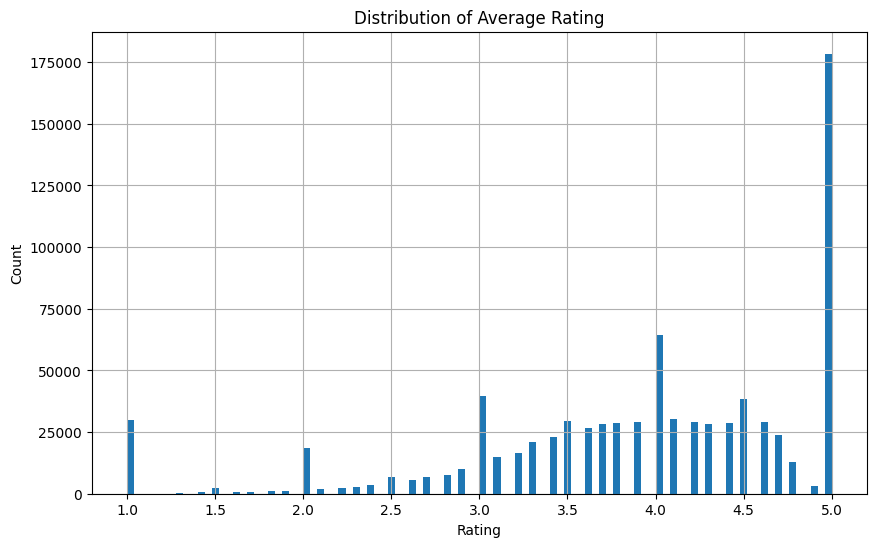

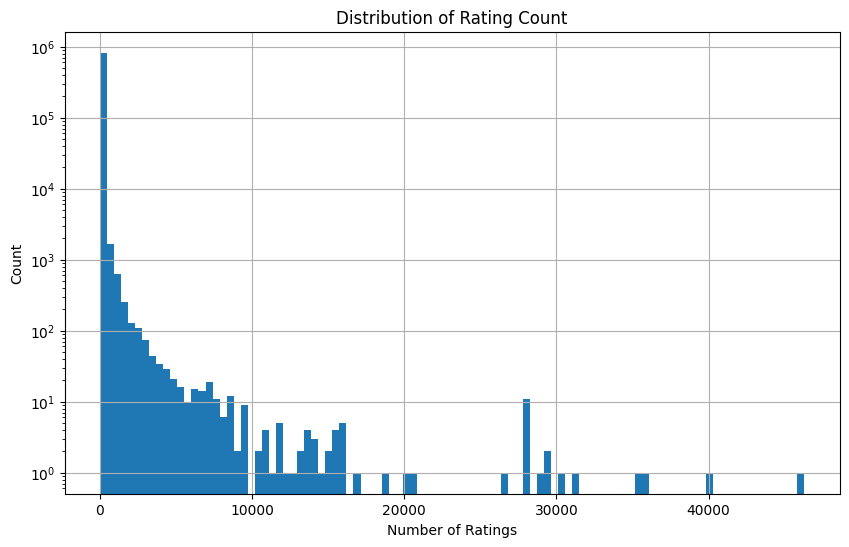

In [20]:
# Ensure white background and bigger size
plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 6)  # Width=10 inches, Height=6 inches

# Histogram for average rating
df["average_rating"].dropna().hist(bins=100)
plt.title("Distribution of Average Rating")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

# Histogram for number of ratings
df["rating_number"].dropna().hist(bins=100)
plt.title("Distribution of Rating Count")
plt.xlabel("Number of Ratings")
plt.ylabel("Count")
plt.yscale("log")  # Use log scale for better visibility
plt.show()

In [21]:
# Now let's check description which is suprisingly a list field (Expected a string)
df["description_length"] = df["description"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

df["description_length"].value_counts().sort_index()

description_length
0      766819
1       48146
2        1705
3         757
4        1000
5         760
6         922
7         617
8         669
9         619
10        533
11        471
12        514
13        342
14        268
15        297
16        227
17        178
18        144
19        109
20        154
21        102
22        116
23         61
24         79
25         88
26         56
27         29
28         53
29         31
30         32
31         25
32         29
33         13
34         23
35          9
36         12
37         11
38         20
39          5
40         12
41          3
42          6
43          1
44          4
45          5
46          8
47          3
48          2
50          3
52          2
54          5
55          2
57          1
58          1
65          1
71          1
75          1
83          1
101         1
Name: count, dtype: int64

In [22]:
# Let's check cases where there are multiple descriptions
df[df["description_length"] > 3].head()["description"].values

array([list(['Brand:MSGUIDE', 'Size:', '28.3"(L) x 25.6"(W)', 'Gender:', 'Unisex', 'Aadjustable:', 'Adjustable Extra Long Ties, suitable for most men and women', 'Waterproof:', 'This apron is made of Oxford cloth, resistant to dirt and abrasion, and can well protect your clothes from oil.', 'Multi-purpose:', 'ideal for kitchen,Cooking,Baking,Barbeque,camping, parties, picnics,garden and so onThe stylish adjustable apron is suitable for most male and female chef artist waiter butchers. This unique apron is perfect for any festive occasions such as cooking, baking, gardening, DIY, party, barbecue, cleaning, painting, etc. If you are a housewife, dining at home, a coffee shop clerk, a painter or some parts that require safety protection, the bib apron to keep your clothes clean.', 'Note:', "Pictures may slightly vary from actual item due to lighting and monitor. So it's normal to have a little bit of chromatic aberration."]),
       list(['Simple fashion clear bracelets, many kinds of sto

We can see that these are just parts of an overall description. Let's concatenate them with space in between list elements

In [23]:
df["description"] = df["description"].apply(
    lambda x: " ".join(x) if isinstance(x, list) else x
)
df = df.drop("description_length", axis=1)

In [24]:
# Lets also remove parent_asin as people usually don't search using ASIN numbers
# This is done in order to reduce the size of the dataset to below 100MB which is the limit by GitHub
df = df.drop("parent_asin", axis=1)

In [25]:
# Set pandas options to display full text in each column
pd.set_option("display.max_colwidth", None)

# Display the first 20 rows of the "main_hi_res_image" column
df["main_hi_res_image"].dropna().head(20)

0     https://m.media-amazon.com/images/I/81XlFXImFrS._AC_UL1500_.jpg
1     https://m.media-amazon.com/images/I/91Z4G2jlFeL._AC_UL1500_.jpg
2     https://m.media-amazon.com/images/I/612-CtsBAvL._AC_UL1500_.jpg
3     https://m.media-amazon.com/images/I/61qmATFO2FL._AC_UL1500_.jpg
4     https://m.media-amazon.com/images/I/91ub366PdKL._AC_UL1500_.jpg
6     https://m.media-amazon.com/images/I/61PXLV7A9DL._AC_UL1500_.jpg
7     https://m.media-amazon.com/images/I/51wifGtXJmL._AC_UL1001_.jpg
8     https://m.media-amazon.com/images/I/61Rz6OajP5L._AC_UL1004_.jpg
9     https://m.media-amazon.com/images/I/71ZtYP0GfdL._AC_UL1500_.jpg
10    https://m.media-amazon.com/images/I/71TvGyW0afL._AC_UL1500_.jpg
11    https://m.media-amazon.com/images/I/71qnfc60uEL._AC_UL1300_.jpg
12    https://m.media-amazon.com/images/I/518JI5jtL8L._AC_UL1000_.jpg
13    https://m.media-amazon.com/images/I/61FYGwTQmzL._AC_UL1200_.jpg
14    https://m.media-amazon.com/images/I/71AqYf+W5FL._AC_UL1500_.jpg
15    https://m.medi

In [26]:
# We observe that URL always starts with "https://m.media-amazon.com/images/I/"
# (Does not necessarily end with ".jpg" as there are .png examples)
# Lets remove this prefix and add it later when we need to display the image
# This will help us reduce the size of the dataset

# Before that, let's validate that all URLs indeed start with this prefix
# Define the expected format
expected_format = r"^https://m\.media-amazon\.com/images/I/.*$"

# Count rows matching the format
matching_rows = df["main_hi_res_image"].str.match(expected_format, na=False).sum()

# Count rows not matching the format
non_matching_rows = df["main_hi_res_image"].notna().sum() - matching_rows

matching_rows, non_matching_rows

(777744, 0)

Indeed, all non-null image links start with the "https://m.media-amazon.com/images/I/" and end with ".jpg". Let's remove these strings from the column

In [27]:
# Remove only the prefix from the URLs
df["main_hi_res_image"] = df["main_hi_res_image"].str.replace(
    r"^https://m\.media-amazon\.com/images/I/", "", regex=True
)

In [28]:
# Optimize data types
df["average_rating"] = df["average_rating"].astype("float32")
df["rating_number"] = df["rating_number"].astype("int32")
df["price"] = df["price"].astype("float32")
df["store"] = df["store"].astype("category")

In [29]:
## Check how many tokens will be needed to vectorize all the text fields

df["token_count"] = df.apply(count_tokens_for_row, axis=1)
total_tokens = df["token_count"].sum()
print(f"Total tokens: {total_tokens}")

Total tokens: 83750299


In [30]:
price_per_1k = 0.00002  # text-embedding-3-small rate
estimated_cost = (total_tokens / 1000) * price_per_1k
print(f"Estimated embedding cost: ${estimated_cost:.2f}")

Estimated embedding cost: $1.68


In [37]:
# Select top products with price information
df_with_price = df[df["price"].notnull()]

# Sort by rating_number descending
df_top = df_with_price.sort_values(by="rating_number", ascending=False).head(1000)

# Save to compressed JSONL
output_top_path = "../backend/data/products.jsonl.gz"
os.makedirs(os.path.dirname(output_top_path), exist_ok=True)
df_top.to_json(
    output_top_path, orient="records", lines=True, compression="gzip", force_ascii=False
)

print(f"✅ Top 1000 products saved to {output_top_path}")

✅ Top 1000 products saved to ../backend/data/products.jsonl.gz
